# Narrative Scene Decoding

### Ian Henriques -- NEU 480 Final Project

In [1]:
# Extra libraries installed in /scratch
import sys
sys.path.insert(0, '/scratch/network/ih2422/lib')

# Importing functions from other files
import narratives_utils

# Pathlib for handling file paths
from pathlib import Path

# Matplotlib for plotting
import matplotlib.pyplot as plt

# Pandas for data manipulation
import pandas as pd

# Display DataFrames without the index column (I saw this trick online)
pd.DataFrame._repr_html_ = lambda self: self.style.hide(axis="index").to_html()

# NumPy for numerical operations
import numpy as np

# Sklearn for machine learning tools
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.model_selection import LeaveOneOut

# Nilearn for neuroimaging data handling
from nilearn import datasets
from nilearn.image import resample_to_img
from nilearn.maskers import NiftiMasker

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Suppress nilearn info-level logs (e.g. dataset found messages)
import logging
logging.getLogger('nilearn').setLevel(logging.WARNING)

### Abstract:

Many regions in the brain, including the place network (PPA, RSC, and OPA) and default mode network (including the mPFC, AG, and PCC), are known to be involved in encoding scene context during audiovisual stimuli. However, it has not been shown that for purely auditory stimuli (i.e., narratives with repeated scene structure), fMRI brain activity is sufficient to decode the current narrative scene. In this study, we analyze Tunnel Under the World (<u>Lositsky et al., 2016</u>; <u>Nastase et al., 2021</u>), a story that cycles between three narrative locations across 8 total scene segments, to determine the extent to which fMRI activity in various areas can predict the identity of each scene. We find that across 20 subjects, several regions show significant above-chance decoding, with the mPFC and PPA showing the strongest effects (mean accuracy 0.64 and 0.53 respectively, chance = 0.33). Also, 18 of 60 cortical parcels survive FDR correction (q = 0.01), concentrated in the default mode network and part of the place network. Representational similarity analysis further reveals structured scene geometry in both the PPA and mPFC. These results demonstrate that even when visual inputs are absent, the mPFC, PPA, and other scene-relevant regions may play a role in maintaining and reinstating scene context during stories.

# Introduction

The Narratives dataset (<u>Nastase et al., 2021</u>) contains stimulus-aligned and motion-corrected fMRI data for several naturalistic stories. This large dataset enables many downstream studies, including decoding story attributes (like the current speaker or emotional valence) from fMRI data timeseries across several subjects.

One of these stories, Tunnel Under the World (`tunnel` for short), comprises 23 subjects prior to filtering, with 25 minutes of data per subject (<u>Lositsky et al., 2016</u>). For the first 14 minutes, the story has a main character named Guy Burkhardt, who experiences each day repeating like the last, cycling through the same three scenes -- Guy's **home**, the **bus**, and his **office** -- until the plot suddenly changes. During this first half of the story, successful comprehension may require subjects to re-instate their models of each scene, so that strange occurrences (such as explosions in Guy's cellar) can be related across different instances of the same scene.

Given this intuition of three scene models that are established and updated at specific points throughout the story, similar to event models (<u>Baldassano et al., 2017</u>), we hypothesize that brain representations (and hence BOLD activity) would be sufficiently separable across scenes to allow a decoder to predict the scene being referred to when each scene begins. Further, we predict that regions typically recruited during *visual* or *audiovisual* scene recognition tasks, such as those in the place network (including the Parahippocampal Place Area, PPA/PHC for short) and the default mode network (including the medial Pre-Frontal Cortex, mPFC for short) would contain scene-specific representations that allow for classification of the correct scene.

Prior fMRI studies of narrative comprehension have examined event structure and temporal patterns in high-level cortical regions (<u>Baldassano et al., 2018</u>; <u>Lerner et al., 2011</u>), but have not directly tested whether the occurrences of the **same scene** can be decoded across event boundaries in a story. Meanwhile, other work has shown that occurrences of the same scene in an *audiovisual* stimulus can have high similarity in certain brain regions (<u>Milivojevic et al., 2016</u>). To our knowledge, the role of scene-relevant regions in decoding scene identity during purely auditory stimuli (e.g., narratives) has not been previously studied in the literature; we investigate it for the first time here.

The specific research questions we aim to answer are:
1. *Can the identity of a recurring scene in an auditory narrative be decoded from fMRI brain activity?*
2. *If so, which brain regions carry the strongest scene-specific representations?*

To test claims of scene decodability, we split the first half of the `tunnel` story into eight distinct *instances*, which represent occurrences of the three scenes: 3 home instances, 3 bus instances, and 2 office instances. Then, we apply standard decoding methods -- support vector machines fit on instance-averaged activity, as well as RSA to quantify scene similarity across instances -- across one subject and several subjects.

Our results show that within-subject scene decoding performance is both *localized to scene-relevant regions* and *statistically significant (when averaged across subjects)*. These findings suggest that scene-relevant regions may have a functional role in maintaining scene-relevant context across different occurrences of the same scene.

# Methods

## Participants

For this study, we begin with 23 participants whose data is present in the Narratives dataset (<u>Nastase et al., 2021</u>). These subjects are fetched from the `sub-###` folders -- subjects which have `func/sub-###_task-tunnel_bold.nii.gz` entries have valid fMRI data from the `tunnel` story. As per the recommendation in the Narratives dataset, we exclude two subjects whose data are of lower quality: `sub-004` and `sub-013`.

In [2]:
# Fetch all tunnel subjects
tunnel_subjects = narratives_utils.fetch_subject_list(
    "tunnel",
    exclude_subjects=["sub-004", "sub-013"]
)
print("Loaded tunnel subjects:", tunnel_subjects)

Loaded tunnel subjects: ['sub-001', 'sub-005', 'sub-022', 'sub-025', 'sub-026', 'sub-041', 'sub-052', 'sub-053', 'sub-055', 'sub-056', 'sub-057', 'sub-058', 'sub-059', 'sub-060', 'sub-061', 'sub-062', 'sub-063', 'sub-064', 'sub-065', 'sub-066', 'sub-069']



As a further quality control step, we also use whole-brain inter-subject correlation (ISC) to filter out subject(s) whose ISC is lower than usual (<u>Hasson et al., 2004</u>, <u>Nastase et al., 2019</u>). This is a common step in functional MRI pipelines that involve multiple subjects, hinging on the assumption that subjects with lower ISC with other subjects may be distracted from the stimulus or may have more pronounced motion artifacts.

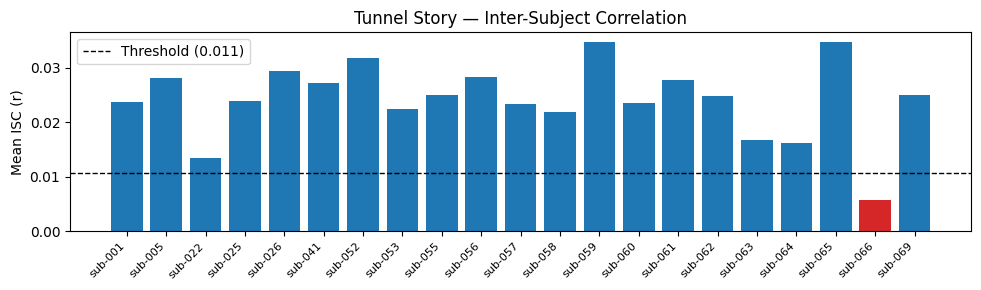

In [3]:
# ISC-based attention filter (based on the ISC approach described in Hasson et al., 2004)
_mni = datasets.load_mni152_brain_mask(resolution=4)
isc_scores, tunnel_subjects_filtered = narratives_utils.isc_filter(
    tunnel_subjects,
    "tunnel",
    _mni,
    title="Tunnel Story — Inter-Subject Correlation"
)

Subject `sub-066` has a mean ISC that is more than two standard deviations below the group mean, suggesting worse BOLD data quality for this specific subject. For this reason, we drop this subject from our analyses.

This leaves **20** subjects after filtering. It is important to note that while filtering subjects, we never exclude subjects on the basis of scene decoding performance; doing so would lead to leakage and over-optimistic results. The remaining subjects are included in every across-subject experiment, regardless of their agreement with our hypotheses.

## Stimuli

All 20 subjects in our study are exposed to the same stimulus: Tunnel Under the World (25 minutes, 34 seconds). Pre-compiled transcripts are available in the Narratives dataset, in the `stimuli/whisperx` folder. By concatenating the `word` fields of `tunnel`'s JSON file, we can derive a plaintext transcript:

In [4]:
# Fetch the transcript from whisperx
whisperx_transcript = narratives_utils.fetch_whisperx_transcript("tunnel")

# Print the beginning of the story
print(whisperx_transcript[:100] + "...")

Tonight, a story by Frederick Pohl, Tunnel Under the World. On the morning of June 15, Guy Burkhardt...


To perform scene decoding, we split the transcript by finding scene instance boundaries using an LLM (Claude Sonnet 4.6). The prompt emphasizes that the language model must find *scene onsets* that could elicit mental images in subjects (such as "in the kitchen, cooking breakfast"). We secure the Claude API key using a vault (to ensure it remains safe on the cluster), then annotate and cache the scenes exactly once with an API call. The result is a set of excerpts which correspond to scene onsets. We manually validate and tweak these scene onsets in the corresponding tab-separated file, where necessary.

In [5]:
# Either annotate the scenes, or read the cached result
out_path = narratives_utils.out_dir / "tunnel_scenes.tsv"
tunnel_scenes = narratives_utils.annotate_scenes(
    "Tunnel Under the World",
    narratives_utils.fetch_whisperx_transcript("tunnel"),
    ["home", "bus", "office"],
    out_path
)

Then, based on the scene onset excerpts, we perform careful scanning of the whisperx transcript's timing using string searching, to determine when each scene instance begins and ends. This helps obtain a start and end timestamp (both in seconds) for each scene instance, such that the end timestamp of one event is the start of the next:

In [6]:
# Fetch the segments for the tunnel story, from the .tsv file from the previous cell
tunnel_segments = narratives_utils.fetch_segments("tunnel")

# Align the annotated scenes to the segments, using the whisperx transcript
tunnel_aligned = narratives_utils.align_tsv_to_whisperx(
    Path("tunnel_scenes.tsv"),
    tunnel_segments,
    narratives_utils.fetch_whisperx_transcript("tunnel")
)

# Print out a table of tunnel segments, with their start and end times
pd.DataFrame(tunnel_aligned)

scene,start,excerpt,end
home,41.855000,"In the kitchen, cooking breakfast.",78.614000
bus,78.614000,"Coming in on the bus,",126.901000
office,126.901000,"the gigantic Contro Chemical building,",224.216000
home,224.216000,got ready for bed.,325.807000
bus,325.807000,took the usual bus to work.,376.447000
office,376.447000,The speaker in the elevator,647.532000
home,647.532000,Guy Burkhart went home,813.766000
bus,813.766000,Guy Burkhardt got on his bus.,859.107000
other,859.107000,"Burkhardt. Here, behind the fence.",1517.970000


The "other" scene category refers to the second half of the story, which does not contain meaningful repetition of scenes. This table can be equivalently shown in the following timeline plot, with a single row per scene category (home, bus, office):

In [7]:
# Colors for the timeline plot
tunnel_colors = {
    "home": "#4C72B0",
    "bus": "#DD8452",
    "office": "#55A868",
    "other": "#bbbbbb"
}

# Labeled scene names
labeled_scenes = ["home", "bus", "office"]

# Instances (ignoring "other" scenes)
instances = [row for row in tunnel_aligned if row["scene"] in labeled_scenes]

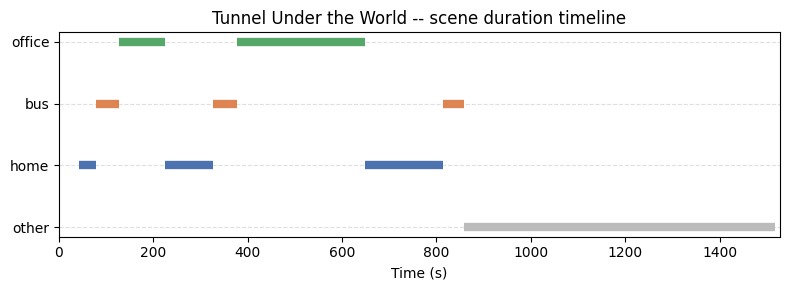

In [8]:
# Plot the scene timeline for the tunnel story
narratives_utils.plot_scene_timeline(
    tunnel_aligned,
    "Tunnel Under the World -- scene duration timeline",
    labeled_scenes,
    tunnel_colors
)

Plotting just the instance onsets (from the start to 10 seconds after the start) helps identify the timing of scene onsets:

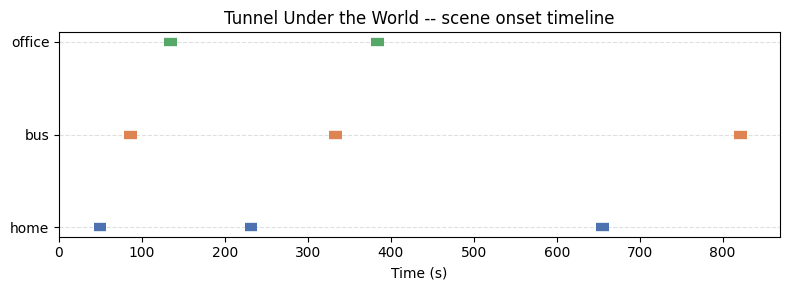

In [9]:
# Plot instance onsets for the tunnel story
narratives_utils.plot_instance_onsets(
    instances,
    "Tunnel Under the World -- scene onset timeline",
    labeled_scenes,
    tunnel_colors
)

For each instance, we use BOLD activity averaged over the *onset* of the instance, rather than the average BOLD activity over the whole instance (i.e., the instance duration). Constructing instance-level BOLD activity for the onsets alone gives us three advantages over the entire instance duration:
1. Since instance onsets are fully non-overlapping, we do not accidentally average activity from multiple scenes when computing the mean BOLD of each instance.
2. Instance onsets do not contain musical or sound effect cues, which could be a potential confounding variable if instance duration were used instead.
3. If we expect subjects to form "mental pictures" that can be decoded using fMRI, we should narrow the stimulus length to only include specific language (at the instance onsets) that elicits mental pictures.

In summary, our effective stimuli (after LLM annotation, transcript alignment, and narrowing to scene onsets) are eight scene instances, each consisting of 10 seconds of brain activity after language that would conjure a mental image of a scene.

## fMRI Data Preprocessing

Since the Narratives dataset already performed motion correction, MNI normalization, and nuisance signal regression, our preprocessing pipeline is simpler compared to papers that collect data from scratch.

Each subject's data is loaded using a custom function we created, `load_bold_masked`. This function can load in BOLD data normally (using BIDS), but can also cache BOLD data for a subject after Nifti masking and other steps (including a resolution change to 4mm). This caching scheme significantly speeds up development, resulting in ~1 second to load BOLD data per subject, rather than ~30 seconds. Caching does not affect performance, since masking and resolution changes are deterministic. Standardization is used (z-scoring each subject's BOLD data across time), to partially account for subject-level scanner drift.

In [10]:
# Load the MNI brain mask at 4mm resolution for later use in loading and processing fMRI data
mni_mask = datasets.load_mni152_brain_mask(resolution=4)

We also account for differences between fMRI and stimulus timing, by hard-coding the Narratives dataset's TR length (1.5 seconds) and hemodynamic lag (4 TRs, or 6 seconds). When loading the averaged BOLD data per instance, we explicitly account for hemodynamic lag by incrementing (by 4) the start and end TRs of the 10-second window corresponding to the instance.

In [11]:
# Constants for fMRI data processing
TR          = 1.5
HRF_LAG_TRS = 4

def instance_BOLD(instance, bold):
    """Extract the mean BOLD pattern for a given scene instance, accounting for the hemodynamic lag."""
    start_tr = int(instance["start"] / TR) + HRF_LAG_TRS
    end_tr   = int(instance["end"]   / TR) + HRF_LAG_TRS
    start_tr, end_tr = start_tr, start_tr + 10
    start_tr = max(0, min(start_tr, len(bold) - 1))
    end_tr   = max(start_tr + 1, min(end_tr, len(bold)))
    return bold[start_tr:end_tr].mean(axis=0)

## Parcellation

We use the Schaefer atlas (400 parcels, 17 networks) for labeling and grouping regions, which helps specify scene-relevant ROIs such as the PPA and mPFC (<u>Schaefer et al., 2018</u>).

For instance, for the PPA, the corresponding Schaefer name is `PHC`. For every one of the parcels with `PHC` in the name (ensuring no other ROI prefixes are triggered), we add them to a growing volume mask, then store that mask for later. Similarly, the mPFC would contain `PFCm` in its Schaefer name -- all parcels containing `PFCm` could be merged, allowing for ROI-specific BOLD activity to be merged as well.

In total, we calculate 10 ROIs. One of these is (trivially) the **Whole Brain**, containing all other parcels. We include three regions from the place network: **PPA** (parahippocampal place area), **RSC** (retrosplenial cortex), **OPA** (occipital place area). Three are from the default mode network: **mPFC** (medial prefrontal cortex), **AG** (angular gyrus), and **PMC** (posterior medial cortex). The final three are low-level regions which serve as controls (we would expect their scene decoding performance to be close to chance): **A1** (primary auditory cortex), **V1** (primary visual cortex), and **S1** (primary somatosensory cortex).

In [12]:
# Schaefer atlas for parcellation and ROI definition
schaefer_atlas = datasets.fetch_atlas_schaefer_2018(
    n_rois=400,
    yeo_networks=17,
    resolution_mm=2,
    verbose=0
)

# Labels for the parcels
schaefer_labels = [l.decode() if isinstance(l, bytes) else l for l in schaefer_atlas.labels]
parcel_labels = {i + 1: lbl for i, lbl in enumerate(schaefer_labels)}

# Build the atlas
ref_masker = NiftiMasker(mask_img=mni_mask, standardize=True)
ref_masker.fit()
schaefer_img  = resample_to_img(
    schaefer_atlas.maps,
    ref_masker.mask_img_,
    interpolation='nearest'
)
schaefer_data = schaefer_img.get_fdata().astype(int)
mask_data     = ref_masker.mask_img_.get_fdata().astype(bool)

# Define ROIs to be used for decoding
roi_searches = [
    ("Whole Brain", [""]),
    ("PPA",         ["PHC"]),
    ("RSC",         ["Rsp"]),
    ("OPA",         ["DorsAttnA_TempOcc", "DorsAttnB_TempOcc"]),
    ("mPFC",        ["PFCm"]),
    ("AG",          ["DefaultB_IPL", "DefaultC_IPL"]),
    ("PMC",         ["_pCun"]),
    ("A1",          ["SomMotB_Aud"]),
    ("V1",          ["Striate"]),
    ("S1",          ["SomMotA"]),
]

# Build masks for each ROI by combining the relevant parcels and applying the brain mask
roi_masks = {}
for roi, searches in roi_searches:
    vol = np.zeros(schaefer_data.shape, dtype=bool)
    for idx, lbl in parcel_labels.items():
        if any(s in lbl for s in searches):
            vol |= (schaefer_data == idx)
    roi_masks[roi] = vol & mask_data

## Single-Subject Scene Decoding

...

In [13]:
def build_X(instances, bold):
    """Build the feature matrix X for instances and corresponding BOLD data."""
    return np.vstack([instance_BOLD(instance, bold) for instance in instances])

# Encode labels once — same for every subject
y = LabelEncoder().fit_transform([instance["scene"] for instance in instances])
num_classes = np.unique(y).size

def evaluate_decoding(X, y):
    """Evaluate the decoding accuracy for a given dataset using leave-one-out cross-validation."""
    pipe  = Pipeline([
        ("scaler", StandardScaler()),
        ("svm",    LinearSVC(max_iter=10000))
    ])
    loo   = LeaveOneOut()
    preds = []
    for train_idx, test_idx in loo.split(X):
        pipe.fit(X[train_idx], y[train_idx])
        pred = pipe.predict(X[test_idx])[0]
        preds.append(pred)
    return np.mean(np.array(preds) == y)

## Averaged Within-Subject Decoding

...

# Results

## Scene Decoding Performance

In [ ]:
subject_acc = {}

for sub_i in tunnel_subjects_filtered:
    data_i = narratives_utils.load_bold_masked(sub_i, "tunnel", mni_mask, standardize=True)
    if data_i is None:
        print(f"{sub_i}  — file missing, skipping")
        continue

    stimulus_duration = data_i.shape[0] * TR

    # ROI accuracies (no feature selection — ROIs already small)
    roi_accs = {}
    for roi, roi_mask in roi_masks.items():
        roi_data_i = data_i[:, roi_mask[mask_data]]
        roi_accs[roi] = evaluate_decoding(build_X(instances, roi_data_i), y)

    subject_acc[sub_i] = roi_accs
    if narratives_utils._VERBOSE:
        print(
            f"{sub_i}  dur={stimulus_duration:.1f}s"
            f"  whole-brain={roi_accs['Whole Brain']:.2f}"
            f"  PHC={roi_accs['PHC']:.2f}  Rsp={roi_accs['Rsp']:.2f}"
            f"  OPA={roi_accs['OPA']:.2f}  mPFC={roi_accs['mPFC']:.2f}"
            f"  AG={roi_accs['AG']:.2f}  PMC={roi_accs['PMC']:.2f}"
            f"  A1={roi_accs['A1']:.2f}  V1={roi_accs['V1']:.2f}  S1={roi_accs['S1']:.2f}"
        )

chance = 1 / num_classes

mean_wb   = np.mean([v["Whole Brain"]   for v in subject_acc.values()])
mean_ppa  = np.mean([v["PPA"]  for v in subject_acc.values()])
mean_rsc  = np.mean([v["RSC"]  for v in subject_acc.values()])
mean_opa  = np.mean([v["OPA"]  for v in subject_acc.values()])
mean_mpfc = np.mean([v["mPFC"] for v in subject_acc.values()])
mean_ag   = np.mean([v["AG"]   for v in subject_acc.values()])
mean_pmc  = np.mean([v["PMC"]  for v in subject_acc.values()])
mean_a1   = np.mean([v["A1"]   for v in subject_acc.values()])
mean_v1   = np.mean([v["V1"]   for v in subject_acc.values()])
mean_s1   = np.mean([v["S1"]   for v in subject_acc.values()])

if narratives_utils._VERBOSE:
    print(
        f"\nMean  whole-brain={mean_wb:.2f}"
        f"  PPA={mean_ppa:.2f}  RSC={mean_rsc:.2f}  OPA={mean_opa:.2f}"
        f"  mPFC={mean_mpfc:.2f}  AG={mean_ag:.2f}  PMC={mean_pmc:.2f}"
        f"  A1={mean_a1:.2f}  V1={mean_v1:.2f}  S1={mean_s1:.2f}"
        f"  (chance={chance:.2f})"
    )
    print(f"Above chance (wb): {sum(v['Whole Brain'] > chance for v in subject_acc.values())}/{len(subject_acc)} subjects")

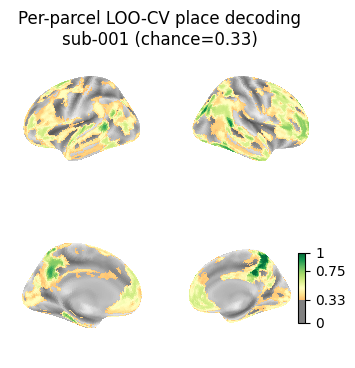

In [15]:
import numpy as np
import matplotlib.pyplot as plt
from nilearn import datasets, plotting, surface
from nilearn.image import new_img_like
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# ── Subject to plot ───────────────────────────────────────────────────────────
surf_sub = tunnel_subjects_filtered[0]
data_sub = narratives_utils.load_bold_masked(surf_sub, "tunnel", mni_mask, standardize=True)

chance = 1 / num_classes
pipe   = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    LinearSVC(max_iter=10000))
])

# ── Per-parcel LOO-CV ─────────────────────────────────────────────────────────
parcel_acc = {}
for parcel_idx in range(1, len(schaefer_labels) + 1):
    parcel_mask = (schaefer_data == parcel_idx) & mask_data
    if parcel_mask.sum() < 5:
        continue
    X_p = build_X(instances, data_sub[:, parcel_mask[mask_data]])
    preds = []
    for i in range(len(X_p)):
        train = [j for j in range(len(X_p)) if j != i]
        pipe.fit(X_p[train], y[train])
        preds.append(pipe.predict(X_p[[i]])[0])
    parcel_acc[parcel_idx] = np.mean(np.array(preds) == y)

best  = max(parcel_acc, key=parcel_acc.get)
worst = min(parcel_acc, key=parcel_acc.get)
if narratives_utils._VERBOSE:
    print(f"Parcels decoded: {len(parcel_acc)}  (chance={chance:.2f})")
    print(f"Best:  {parcel_labels[best]}  acc={parcel_acc[best]:.2f}")
    print(f"Worst: {parcel_labels[worst]}  acc={parcel_acc[worst]:.2f}")

# ── Build result volume ───────────────────────────────────────────────────────
result_vol = np.zeros(schaefer_data.shape)
for idx, acc in parcel_acc.items():
    result_vol[schaefer_data == idx] = acc
result_img = new_img_like(schaefer_img, result_vol)

# ── Surface plot ──────────────────────────────────────────────────────────────
fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
fig = plt.figure(figsize=(4, 4))
fig.suptitle(
    f'Per-parcel LOO-CV place decoding\n{surf_sub} (chance={chance:.2f})',
    fontsize=12
)
for i, (hemi, view) in enumerate([
    ('left',  'lateral'),
    ('right', 'lateral'),
    ('left',  'medial'),
    ('right', 'medial'),
]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'],
        texture,
        hemi=hemi,
        view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='RdYlGn',
        vmax=1.0,
        threshold=chance,
        colorbar=(i == 3),
        symmetric_cbar=False,
        axes=ax,
    )
plt.show()

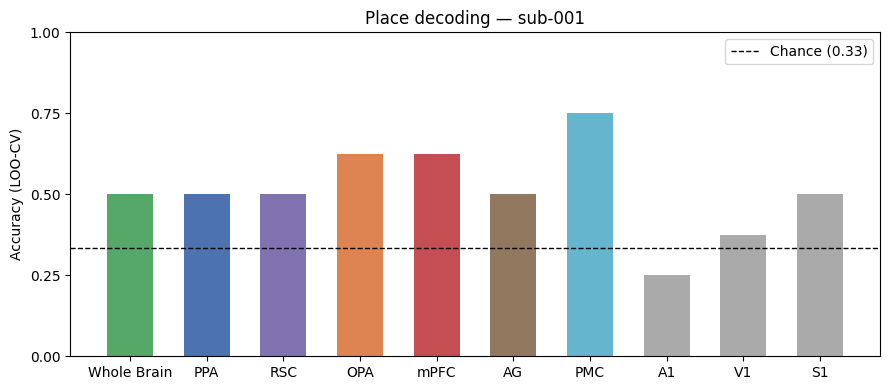

In [16]:
import numpy as np
import matplotlib.pyplot as plt

sub1   = tunnel_subjects_filtered[0]
acc    = subject_acc[sub1]
chance = 1 / num_classes

rois   = ["Whole Brain",  "PPA",    "RSC",    "OPA",    "mPFC",    "AG",      "PMC",    "A1",      "V1",      "S1"]
colors = ["#55A868", "#4C72B0", "#8172B2", "#DD8452", "#C44E52", "#937860", "#64B5CD", "#aaaaaa", "#aaaaaa", "#aaaaaa"]
values = [acc[r] for r in rois]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(rois, values, color=colors, width=0.6)
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Place decoding — {sub1}')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()

## Averaged Within-Subject Results

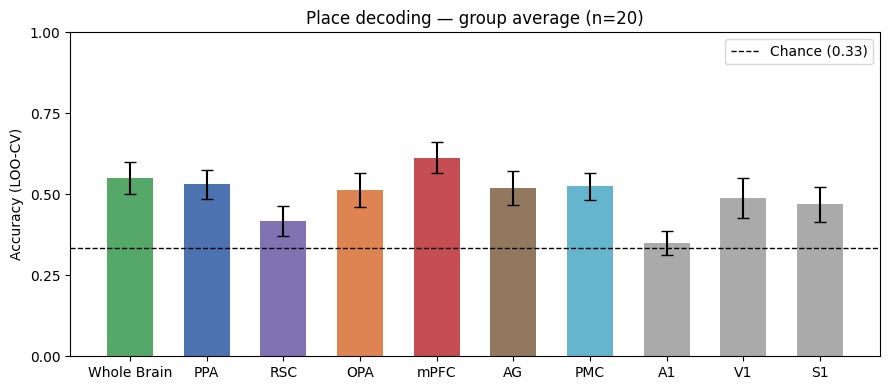

In [18]:
from scipy import stats

rois   = ["Whole Brain",  "PPA",    "RSC",    "OPA",    "mPFC",    "AG",      "PMC",    "A1",      "V1",      "S1"]
colors = ["#55A868", "#4C72B0", "#8172B2", "#DD8452", "#C44E52", "#937860", "#64B5CD", "#aaaaaa", "#aaaaaa", "#aaaaaa"]

means = [np.mean([v[r] for v in subject_acc.values()]) for r in rois]
sems  = [stats.sem([v[r] for v in subject_acc.values()]) for r in rois]

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(
    rois, means,
    yerr=sems, color=colors, width=0.6,
    capsize=4, error_kw=dict(elinewidth=1.5)
)
ax.axhline(chance, color='black', linestyle='--', linewidth=1, label=f'Chance ({chance:.2f})')
ax.set_ylabel('Accuracy (LOO-CV)')
ax.set_title(f'Place decoding — group average (n={len(subject_acc)})')
ax.set_ylim(0, 1)
ax.set_yticks(np.arange(0, 1.1, 0.25))
ax.legend()
plt.tight_layout()
plt.show()

In [20]:
import re

def parcel_to_group(lbl):
    lbl = re.sub(r'^17Networks_[LR]H_', '', lbl)
    lbl = re.sub(r'_\d+$', '', lbl)
    return lbl

parcel_groups = {
    idx: parcel_to_group(lbl)
    for idx, lbl in parcel_labels.items()
    if parcel_to_group(lbl) != 'Background'
}

group_parcels = {}
for idx, g in parcel_groups.items():
    group_parcels.setdefault(g, []).append(idx)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("svm",    LinearSVC(max_iter=10000))
])

group_acc_all = {g: [] for g in group_parcels}

for sub in tunnel_subjects_filtered:
    data_sub = narratives_utils.load_bold_masked(sub, "tunnel", mni_mask, standardize=True)
    if data_sub is None:
        continue
    for g, idxs in group_parcels.items():
        vol = np.zeros(schaefer_data.shape, dtype=bool)
        for idx in idxs:
            vol |= (schaefer_data == idx)
        group_mask = (vol & mask_data)[mask_data]
        if group_mask.sum() < 5:
            continue
        X_p = build_X(instances, data_sub[:, group_mask])
        preds = []
        for i in range(len(X_p)):
            train = [j for j in range(len(X_p)) if j != i]
            pipe.fit(X_p[train], y[train])
            preds.append(pipe.predict(X_p[[i]])[0])
        group_acc_all[g].append(np.mean(np.array(preds) == y))
    if narratives_utils._VERBOSE:
        print(f"{sub} done")

In [21]:
from statsmodels.stats.multitest import multipletests
import pandas as pd

N_PERM = 100000
rng = np.random.default_rng(42)

def permutation_test_mean(accs, chance, n_perm=10000):
    accs = np.array(accs)
    obs = accs.mean()
    centered = accs - chance
    signs = rng.choice([-1, 1], size=(n_perm, len(accs)))
    null_dist = (signs * centered).mean(axis=1)
    p = (null_dist >= obs - chance).mean()
    return obs, p

group_names, mean_accs, p_vals = [], [], []
for g, accs in group_acc_all.items():
    if len(accs) < 2:
        continue
    mean_acc, p = permutation_test_mean(accs, chance, N_PERM)
    group_names.append(g)
    mean_accs.append(mean_acc)
    p_vals.append(p)

group_names = np.array(group_names)
mean_accs   = np.array(mean_accs)
p_vals      = np.array(p_vals)

reject, p_fdr, _, _ = multipletests(p_vals, alpha=0.01, method='fdr_bh')

print(f"{reject.sum()} / {len(reject)} parcels significant (FDR q=0.01)\n")

df = pd.DataFrame(columns=[
    "Parcel Group",
    "Mean Accuracy",
    "p-value (FDR)"
])

for group, mean, p_val, reject_null in sorted(zip(group_names, mean_accs, p_fdr, reject), key=lambda x: -x[1]):
    if reject_null:
        df.loc[len(df)] = [group, mean, p_val]
        # print(f"* {group:<20s} mean_acc={mean:.3f}  p_fdr={p_val:.3f}")

df

18 / 60 parcels significant (FDR q=0.01)



Parcel Group,Mean Accuracy,p-value (FDR)
TempPar,0.643750,0.000000
DefaultA_PFCm,0.637500,0.000200
DefaultB_Temp,0.618750,0.000257
DefaultB_IPL,0.593750,0.000450
DefaultB_PFCd,0.593750,0.000150
DefaultB_PFCv,0.581250,0.000200
ContA_PFCl,0.568750,0.000150
ContB_PFClv,0.543750,0.000150
DefaultC_PHC,0.531250,0.001440
DorsAttnA_ParOcc,0.525000,0.000467


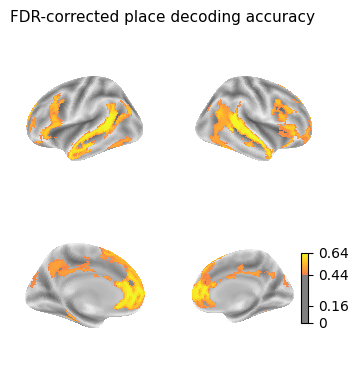

In [22]:
from nilearn import plotting, surface
from nilearn.image import new_img_like

result_vol = np.full(schaefer_data.shape, np.nan)
for g, acc, r in zip(group_names, mean_accs, reject):
    if not r:
        continue
    for idx, grp in parcel_groups.items():
        if grp == g:
            result_vol[schaefer_data == idx] = acc

result_img = new_img_like(schaefer_img, np.where(np.isnan(result_vol), 0, result_vol))

fsaverage = datasets.fetch_surf_fsaverage('fsaverage5')
acc_min = mean_accs[reject].min() if reject.any() else 0.0

fig = plt.figure(figsize=(4, 4))
fig.suptitle('FDR-corrected place decoding accuracy', fontsize=11)
for i, (hemi, view) in enumerate([('left','lateral'), ('right','lateral'),
                                    ('left','medial'),  ('right','medial')]):
    texture = surface.vol_to_surf(result_img, fsaverage[f'pial_{hemi}'])
    ax = fig.add_subplot(2, 2, i + 1, projection='3d')
    plotting.plot_surf_stat_map(
        fsaverage[f'infl_{hemi}'], texture,
        hemi=hemi, view=view,
        bg_map=fsaverage[f'sulc_{hemi}'],
        cmap='plasma', threshold=acc_min,
        colorbar=(i == 3), symmetric_cbar=False, axes=ax,
    )
plt.show()

## Scene-Level RSA

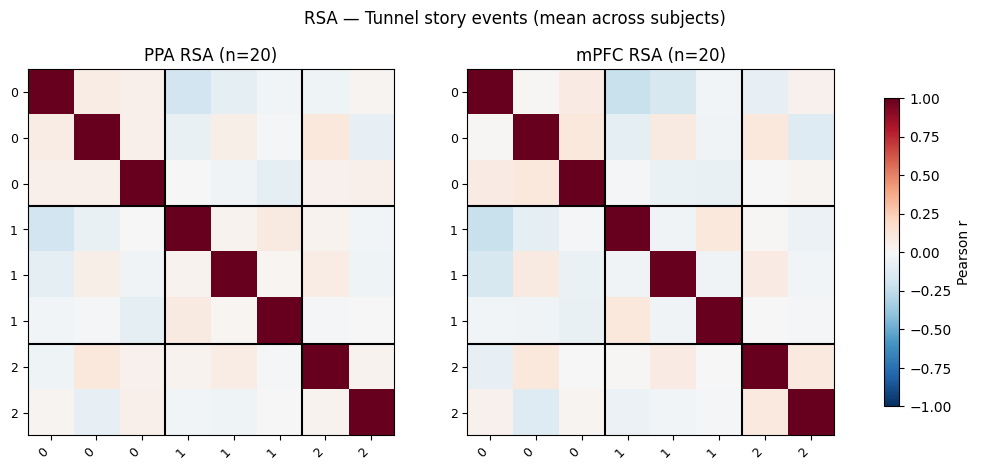

In [25]:
import numpy as np
import matplotlib.pyplot as plt

# Collect per-subject RSA matrices — PPA and mPFC
rsa_ppa_list  = []
rsa_mpfc_list = []

ppa_voxels  = roi_masks["PPA"][mask_data]
mpfc_voxels = roi_masks["mPFC"][mask_data]

for sub_i in tunnel_subjects_filtered:
    data_i = narratives_utils.load_bold_masked(sub_i, 'tunnel', mni_mask, standardize=True)
    if data_i is None:
        continue
    X_ppa  = build_X(instances, data_i[:, ppa_voxels])
    X_mpfc = build_X(instances, data_i[:, mpfc_voxels])
    rsa_ppa_list.append(np.corrcoef(X_ppa))
    rsa_mpfc_list.append(np.corrcoef(X_mpfc))

mean_ppa  = np.mean(rsa_ppa_list,  axis=0)
mean_mpfc = np.mean(rsa_mpfc_list, axis=0)

# Sort events by place label
scene_labels  = y
sort_order    = sorted(range(len(instances)), key=lambda i: scene_labels[i])
sorted_labels = [scene_labels[i] for i in sort_order]

# Group boundary positions
counts, prev = [], None
for lbl in sorted_labels:
    if lbl != prev:
        counts.append(1)
        prev = lbl
    else:
        counts[-1] += 1

def _plot_rsa(ax, matrix, title):
    mat_sorted = matrix[np.ix_(sort_order, sort_order)]
    img = ax.imshow(mat_sorted, cmap='RdBu_r', vmin=-1, vmax=1)
    cum = 0
    for c in counts[:-1]:
        cum += c
        ax.axhline(cum - 0.5, color='k', linewidth=1.5)
        ax.axvline(cum - 0.5, color='k', linewidth=1.5)
    ax.set_xticks(range(len(sorted_labels)))
    ax.set_yticks(range(len(sorted_labels)))
    ax.set_xticklabels(sorted_labels, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(sorted_labels, fontsize=9)
    ax.set_title(title)
    return img

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
_plot_rsa(axes[0], mean_ppa,  f'PPA RSA (n={len(rsa_ppa_list)})')
img = _plot_rsa(axes[1], mean_mpfc, f'mPFC RSA (n={len(rsa_mpfc_list)})')
fig.colorbar(img, ax=axes, label='Pearson r', shrink=0.8)
plt.suptitle('RSA — Tunnel story events (mean across subjects)', fontsize=12)
plt.show()

# Discussion

(<u>O'Craven et al., 2000</u>)

(<u>Hausler et al., 2022</u>)

(<u>Aziz et al., 2008</u>)

# Future Work

## Cross-Subject Decoding

## Other Narratives

# References

**Note:** I used Google Scholar to copy the BibTeX citations for each source, which I list below:

**Aziz et al., 2008**
* @article{aziz2008modulation,
    title={Modulation of the FFA and PPA by language related to faces and places},
    author={Aziz-Zadeh, Lisa and Fiebach, Christian J and Naranayan, Srini and Feldman, Jerome and Dodge, Ellen and Ivry, Richard B},
    journal={Social Neuroscience},
    volume={3},
    number={3-4},
    pages={229--238},
    year={2008},
    publisher={Taylor \& Francis}
  }

**Baldassano et al., 2017**
* @article{baldassano2017discovering,
    title={Discovering event structure in continuous narrative perception and memory},
    author={Baldassano, Christopher and Chen, Janice and Zadbood, Asieh and Pillow, Jonathan W and Hasson, Uri and Norman, Kenneth A},
    journal={Neuron},
    volume={95},
    number={3},
    pages={709--721},
    year={2017},
    publisher={Elsevier}
  }

**Baldassano et al., 2018**
* @article{baldassano2018representation,
    title={Representation of real-world event schemas during narrative perception},
    author={Baldassano, Christopher and Hasson, Uri and Norman, Kenneth A},
    journal={Journal of Neuroscience},
    volume={38},
    number={45},
    pages={9689--9699},
    year={2018},
    publisher={Society for Neuroscience}
  }

**Hasson et al., 2004**
* @article{hasson2004intersubject,
    title={Intersubject synchronization of cortical activity during natural vision},
    author={Hasson, Uri and Nir, Yuval and Levy, Ifat and Fuhrmann, Galit and Malach, Rafael},
    journal={science},
    volume={303},
    number={5664},
    pages={1634--1640},
    year={2004},
    publisher={American Association for the Advancement of Science}
  }

**Hausler et al., 2022**
* @article{hausler2022processing,
    title={Processing of visual and non-visual naturalistic spatial information in the" parahippocampal place area"},
    author={H{\"a}usler, Christian O and Eickhoff, Simon B and Hanke, Michael},
    journal={Scientific data},
    volume={9},
    number={1},
    pages={147},
    year={2022},
    publisher={Nature Publishing Group UK London}
  }

**Lerner at al., 2011**
* @article{lerner2011topographic,
    title={Topographic mapping of a hierarchy of temporal receptive windows using a narrated story},
    author={Lerner, Yulia and Honey, Christopher J and Silbert, Lauren J and Hasson, Uri},
    journal={Journal of neuroscience},
    volume={31},
    number={8},
    pages={2906--2915},
    year={2011},
    publisher={Society for Neuroscience}
  }

**Lositsky et al., 2016**
* @article{
    lositsky2016neural,
    title={Neural pattern change during encoding of a narrative predicts retrospective duration estimates},
    author={Lositsky, Olga and Chen, Janice and Toker, Daniel and Honey, Christopher J and Shvartsman, Michael and Poppenk, Jordan L and Hasson, Uri and Norman, Kenneth A},
    journal={elife},
    volume={5},
    pages={e16070},
    year={2016},
    publisher={eLife Sciences Publications, Ltd}
  }

**Milovojevic et al., 2016**
* @article{milivojevic2016coding,
    title={Coding of event nodes and narrative context in the hippocampus},
    author={Milivojevic, Branka and Varadinov, Meryl and Vicente Grabovetsky, Alejandro and Collin, Silvy HP and Doeller, Christian F},
    journal={The Journal of Neuroscience},
    volume={36},
    number={49},
    pages={12412--12424},
    year={2016},
    publisher={Society for Neuroscience}
}

**Nastase et al., 2019:**
* @misc{nastase2019measuring,
    title={Measuring shared responses across subjects using intersubject correlation},
    author={Nastase, Samuel A and Gazzola, Valeria and Hasson, Uri and Keysers, Christian},
    journal={Social cognitive and affective neuroscience},
    volume={14},
    number={6},
    pages={667--685},
    year={2019},
    publisher={Oxford University Press}
  }

**Nastase et al., 2021:**
* @article{
    nastase2021narratives,
    title={The “Narratives” fMRI dataset for evaluating models of naturalistic language comprehension},
    author={Nastase, Samuel A and Liu, Yun-Fei and Hillman, Hanna and Zadbood, Asieh and Hasenfratz, Liat and Keshavarzian, Neggin and Chen, Janice and Honey, Christopher J and Yeshurun, Yaara and Regev, Mor and others},
    journal={Scientific data},
    volume={8},
    number={1},
    pages={250},
    year={2021},
    publisher={Nature Publishing Group UK London}
  }

**O'Craven et al., 2000**
* @article{o2000mental,
    title={Mental imagery of faces and places activates corresponding stimulus-specific brain regions},
    author={O'Craven, Kathleen M and Kanwisher, Nancy},
    journal={Journal of cognitive neuroscience},
    volume={12},
    number={6},
    pages={1013--1023},
    year={2000},
    publisher={MIT Press One Rogers Street, Cambridge, MA 02142-1209, USA journals-info~…}
  }

**Schaefer et al., 2018**
* @article{schaefer2018local,
    title={Local-global parcellation of the human cerebral cortex from intrinsic functional connectivity MRI},
    author={Schaefer, Alexander and Kong, Ru and Gordon, Evan M and Laumann, Timothy O and Zuo, Xi-Nian and Holmes, Avram J and Eickhoff, Simon B and Yeo, BT Thomas},
    journal={Cerebral cortex},
    volume={28},
    number={9},
    pages={3095--3114},
    year={2018},
    publisher={Oxford University Press}
  }

# AI Appendix

For my project, all of the code for the main figures in the Results section were created by me. AI models did not write the decoding or graphing code directly; although I sometimes implemented suggestions from AI, I am responsible for fMRI processing and figure formatting code in the Methods and Results sections of this report.

I did use an AI agent (Claude Code) as a post-processing helper for my notebook. In particular, I used Claude Code for five main purposes:
1. Cleaning up formatting, since my code structure was somewhat inconsistent across cells. Since LLMs are reasonably good at reformatting existing code, I used Claude Code to reformat my code, using tabs appropriately, splitting lines of code that were too long, and improving docstring consistency. This bullet point applies both to this notebook (main.ipynb) but also the narratives_utils Python file.
2. As a "peer reviewer" for my code implementation - every time I completed a code cell, I would ask Claude Code to review the cell, to check if the logic is sound. In a couple spots, the agent suggested I slightly tweak my methods so the results became clearer. For instance, AI suggested that I use q = 0.01, rather than q = 0.05 - this helped me focus my analysis on more significant regions. Also, Claude Code helped me make a cleaner timeline plot by suggesting I use different rows (one per scene type). While this was not *necessary* for my project, these contributions from AI helped me make my methods clearer while leaving most of my code the same.
3. Writing a prompt for the initial segmentation of the story into scenes (I told Claude Code what I wanted the segmentation to do, then it wrote a prompt), and calling Claude Sonnet (the API version) to segment the story for me. I also instructed Claude Code to help me create a vault (claude_api_key.py), which hides my API key on Adroit for security purposes. Claude's involvement in the scene segmentation process helped save me a bit of time in figuring out exactly where scene boundaries were, but I later checked and adjusted boundaries that didn't make sense to me.
4. Claude Code helped me rapidly prototype some of the future work sections that I was struggling with, to make sure that my other experiments (like SRM and HMM) were on the right track. For instance, when I realized I was not getting good cross-subject decoding accuracy, I used Claude Code to run a bunch of experiments. I made sure to read the code after each generation, to make sure it made sense to me. I also wrote unit tests for these future work sections, using simulated brain signals, to make sure they were implemented properly. In this regard, Claude Code also helped me resolve import errors with brainiak SRM - on the top of narratives_utils.py, there is a statement involving "mpi4py" -- I did not write this, but it helped me resolve a dependency conflict so I could use SRM in the future work section.
5. I used Claude Sonnet (both the web interface and Claude Code) to help me find relevant papers to cite in my report. After reading the abstracts, introductions, and conclusions of each, I could decide whether to include them here.